In [1]:
#Importar las librerias
from pathlib import Path
import sys

# Carpeta raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

    
import os
import pandas as pd
import random
from core.SimularDataset import SimuladorDataset
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from collections import defaultdict
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')



In [19]:
# Función que crea la carpeta data_simulada si no existe.
# Por cada paciente y fase, genere el dataset. Además, guarda un CSV por paciente y fase en una subcarpeta
# data_simulada/paciente_id/.
# Genera un CSV combinado con todos los pacientes y fases

def generar_y_guardar_datasets(pacientes, fases, duracion_por_fase=600, carpeta_base="/data_simulada"):
    os.makedirs(carpeta_base, exist_ok=True)
    dfs_combinados = []

    for paciente in pacientes:
        carpeta_paciente = os.path.join(carpeta_base, paciente)
        os.makedirs(carpeta_paciente, exist_ok=True)

        for fase in fases:
            simulador = SimuladorDataset(paciente_id=paciente, fase_ela=fase, duracion=duracion_por_fase)
            df = simulador.generar()

            # Añadir columnas para identificar paciente y fase si no están explícitas
            if 'paciente_id' not in df.columns:
                df['paciente_id'] = paciente
            if 'fase_ela' not in df.columns:
                df['fase_ela'] = fase

            dfs_combinados.append(df)

            # Guardar CSV individual por paciente y fase
            nombre_archivo = f"{paciente}_fase{fase}.csv"
            ruta_archivo = os.path.join(carpeta_paciente, nombre_archivo)
            df.to_csv(ruta_archivo, index=False)
            print(f"Guardado: {ruta_archivo}")

    # Guardar un CSV combinado con todos los datos
    df_todos = pd.concat(dfs_combinados, ignore_index=True)
    ruta_combinado = os.path.join(carpeta_base, "dataset_sintetico_completo.csv")
    df_todos.to_csv(ruta_combinado, index=False)
    print(f"Guardado dataset combinado: {ruta_combinado}")

    return df_todos


In [20]:
# Se generan los datos de 4 pacientes
pacientes = ["PAC_001", "PAC_002", "PAC_003", "PAC_004"]
fases = [1, 2, 3]
df_final = generar_y_guardar_datasets(pacientes, fases)

Guardado: /data_simulada\PAC_001\PAC_001_fase1.csv
Guardado: /data_simulada\PAC_001\PAC_001_fase2.csv
Guardado: /data_simulada\PAC_001\PAC_001_fase3.csv
Guardado: /data_simulada\PAC_002\PAC_002_fase1.csv
Guardado: /data_simulada\PAC_002\PAC_002_fase2.csv
Guardado: /data_simulada\PAC_002\PAC_002_fase3.csv
Guardado: /data_simulada\PAC_003\PAC_003_fase1.csv
Guardado: /data_simulada\PAC_003\PAC_003_fase2.csv
Guardado: /data_simulada\PAC_003\PAC_003_fase3.csv
Guardado: /data_simulada\PAC_004\PAC_004_fase1.csv
Guardado: /data_simulada\PAC_004\PAC_004_fase2.csv
Guardado: /data_simulada\PAC_004\PAC_004_fase3.csv
Guardado dataset combinado: /data_simulada\dataset_sintetico_completo.csv


In [21]:
df = pd.read_csv("/data_simulada/dataset_sintetico_completo.csv") # Se importa el CSV

In [23]:
df.head()

,timestamp,paciente_id,fase_ela,aceleracion_x,aceleracion_y,aceleracion_z,magnitud_movimiento,actividad_estimada,evento_inmovilidad,estado,...,hipovent_sostenido,senal_sueno,fase_sueno,evento_fragmentacion,frag_sueno_sostenido,inmovilidad_sostenida_etiqueta,hipoxia_sostenida_etiqueta,hipovent_sostenida,frag_sueno_sostenido_etiqueta,empeoramiento
0,2026-07-04 23:43:17.008779,PAC_001,1,0.094756,-0.023578,0.997055,1.001825,0.032598,0,reposo,...,0.0,0.000745,LIGHT,0.0,0.0,0,0,0,0,0
1,2026-07-04 23:43:17.108779,PAC_001,1,0.076020,0.047463,1.030534,1.034423,0.012157,0,reposo,...,0.0,0.000745,LIGHT,0.0,0.0,0,0,0,0,0
2,2026-07-04 23:43:17.208779,PAC_001,1,-0.050806,-0.048624,1.023727,1.026140,0.007786,1,reposo,...,0.0,0.000745,LIGHT,0.0,0.0,0,0,0,0,0
3,2026-07-04 23:43:17.308779,PAC_001,1,0.032727,-0.058018,1.016671,1.018851,0.045726,0,reposo,...,0.0,0.000745,LIGHT,0.0,0.0,0,0,0,0,0
4,2026-07-04 23:43:17.408779,PAC_001,1,0.079446,0.033846,0.930689,0.934687,0.018452,0,reposo,...,0.0,0.000745,LIGHT,0.0,0.0,0,0,0,0,0


In [24]:
# ================================
# INFORMACIÓN BÁSICA DEL DATASET
# ================================
print(df.shape)

(72000, 32)


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72000 entries, 0 to 71999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   timestamp                       72000 non-null  str    
 1   paciente_id                     72000 non-null  str    
 2   fase_ela                        72000 non-null  int64  
 3   aceleracion_x                   72000 non-null  float64
 4   aceleracion_y                   72000 non-null  float64
 5   aceleracion_z                   72000 non-null  float64
 6   magnitud_movimiento             72000 non-null  float64
 7   actividad_estimada              72000 non-null  float64
 8   evento_inmovilidad              72000 non-null  int64  
 9   estado                          72000 non-null  str    
 10  inmovilidad_sostenida           72000 non-null  int64  
 11  spo2                            71940 non-null  float64
 12  frecuencia_cardiaca             71940 non-n

In [26]:
df.describe()

,fase_ela,aceleracion_x,aceleracion_y,aceleracion_z,magnitud_movimiento,actividad_estimada,evento_inmovilidad,inmovilidad_sostenida,spo2,frecuencia_cardiaca,...,evento_brp,hipovent_sostenido,senal_sueno,evento_fragmentacion,frag_sueno_sostenido,inmovilidad_sostenida_etiqueta,hipoxia_sostenida_etiqueta,hipovent_sostenida,frag_sueno_sostenido_etiqueta,empeoramiento
count,72000.000000,72000.000000,72000.000000,72000.000000,72000.000000,7.200000e+04,72000.000000,72000.000000,71940.000000,71940.000000,...,71940.000000,71940.000000,71952.000000,71952.000000,71952.000000,72000.000000,72000.000000,72000.000000,72000.000000,72000.000000
mean,2.000000,0.000043,-0.000076,1.000065,1.016505,3.356708e-02,0.318792,0.165986,92.336053,81.029099,...,0.147832,0.301640,0.001651,0.022793,0.577051,0.165986,0.214583,0.301667,0.577333,0.788653
std,0.816502,0.062184,0.173654,0.062302,0.068926,3.326004e-02,0.466011,0.372071,3.835454,10.359996,...,0.354935,0.458973,0.298903,0.149244,0.494031,0.372071,0.410536,0.458985,0.493987,0.408267
min,1.000000,-0.360189,-0.720700,0.639108,0.649059,5.869331e-07,0.000000,0.000000,82.695193,57.150233,...,0.000000,0.000000,-0.966932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,-0.029503,-0.051740,0.970136,0.983598,7.087853e-03,0.000000,0.000000,90.083279,72.603294,...,0.000000,0.000000,-0.200311,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2.000000,-0.000118,-0.000102,0.999932,1.006210,2.332745e-02,0.000000,0.000000,92.966713,80.763059,...,0.000000,0.000000,-0.000002,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,3.000000,0.029852,0.051177,1.029499,1.053463,5.055847e-02,1.000000,0.000000,95.441032,89.518606,...,0.000000,1.000000,0.204675,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,3.000000,0.406544,0.760378,1.425405,1.448288,2.789667e-01,1.000000,1.000000,99.100942,104.374624,...,1.000000,1.000000,0.933784,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
print("Eventos de hipoxia:", df['hipoxia_sostenida'].sum())
print("Eventos de hipoventilación:", df['hipovent_sostenido'].sum())
print("Eventos de inmovilidad:", df['inmovilidad_sostenida'].sum())
print("Eventos de fragmentación de sueño:", df['frag_sueno_sostenido'].sum())
print("Eventos de empeoramiento global:", df['empeoramiento'].sum())


Eventos de hipoxia: 15430.0
Eventos de hipoventilación: 21700.0
Eventos de inmovilidad: 11951
Eventos de fragmentación de sueño: 41520.0
Eventos de empeoramiento global: 56783


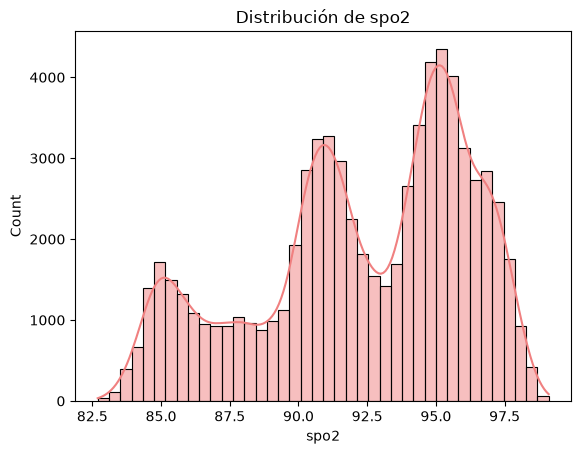

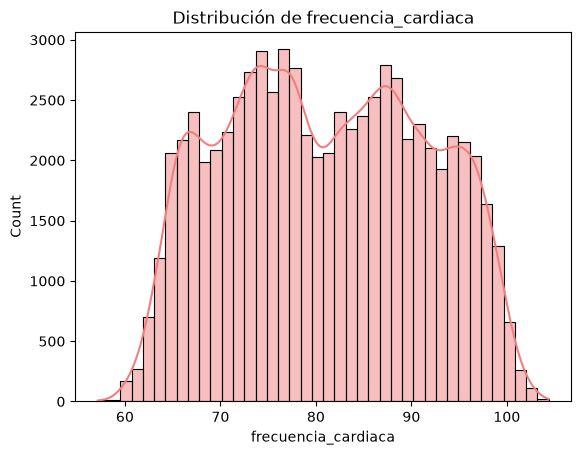

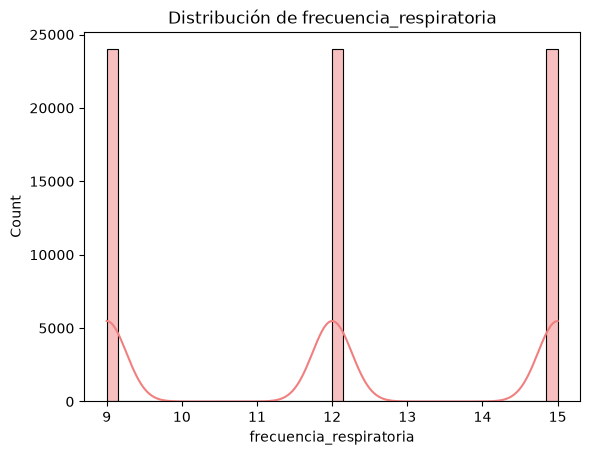

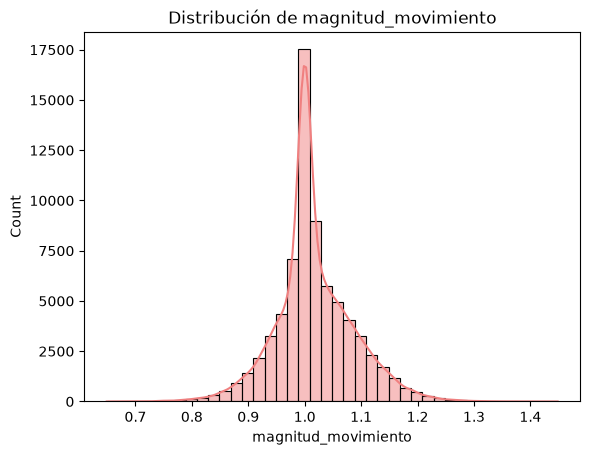

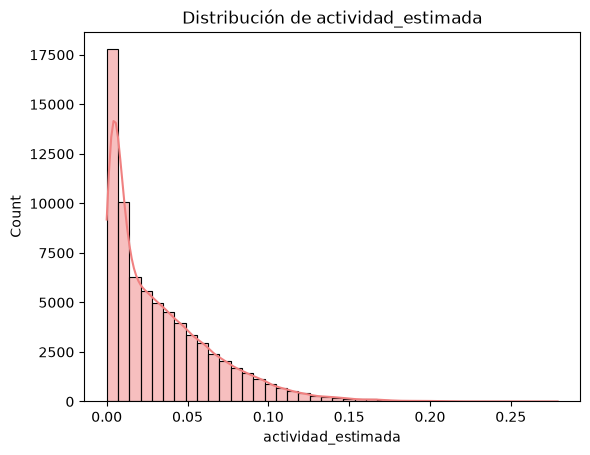

In [28]:
# ================================
# ANÁLISIS EXPLORATORIO
# ================================
variables_clave = [
    "spo2", "frecuencia_cardiaca", "frecuencia_respiratoria",
    "magnitud_movimiento", "actividad_estimada"
]


for col in variables_clave:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=40, color="lightcoral")
    plt.title(f"Distribución de {col}")
    plt.show()

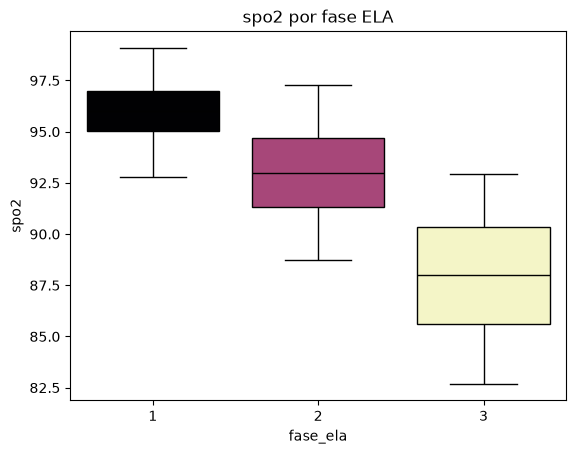

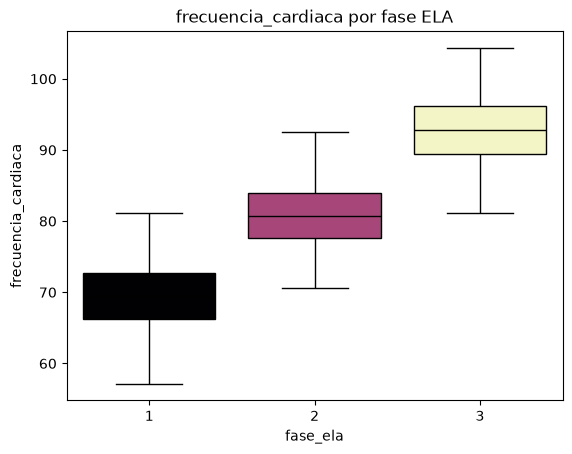

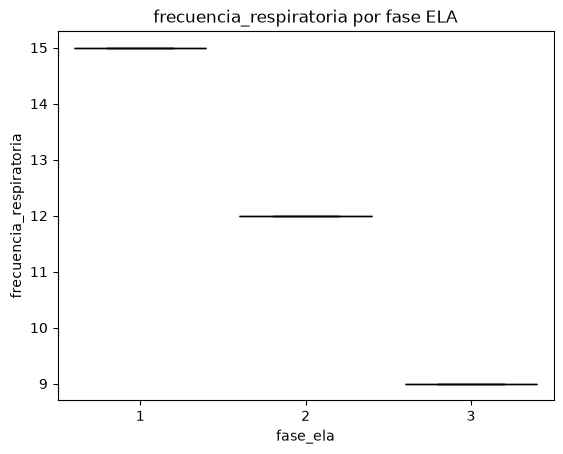

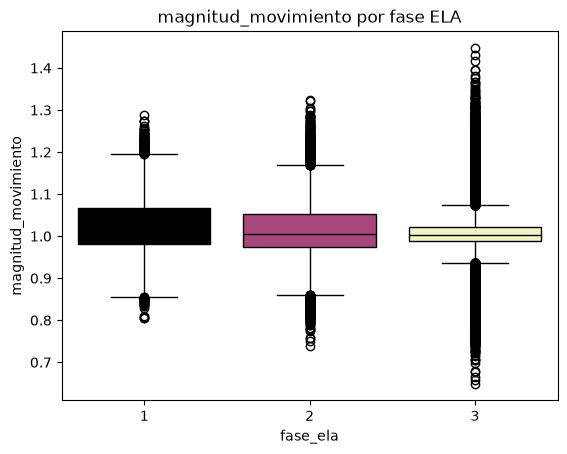

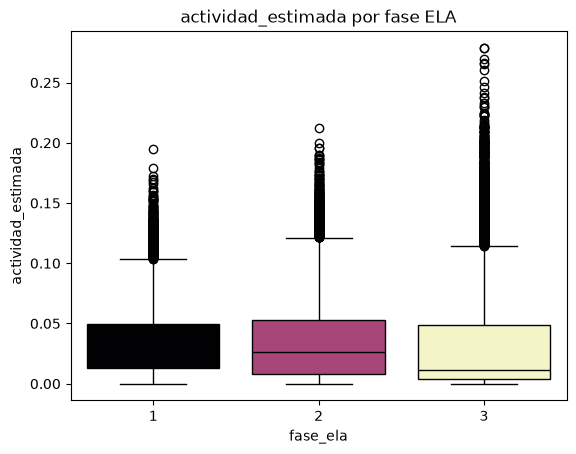

In [29]:
# Boxplots por fase de ELA
for col in variables_clave:
    plt.figure()
    sns.boxplot(data=df, x="fase_ela", y=col, hue="fase_ela", palette="magma", legend=False)
    plt.title(f"{col} por fase ELA")
    plt.show()

In [30]:
# Distribución de Sp02 por fase de ELA
fig = px.histogram(df, x="spo2", nbins=40, color="fase_ela",
                   title="Distribución de SpO₂ por fase de ELA",
                   labels={"spo2": "SpO₂ (%)", "fase_ela": "Fase ELA"},
                   marginal="box")
fig.update_layout(bargap=0.1)
fig.show()

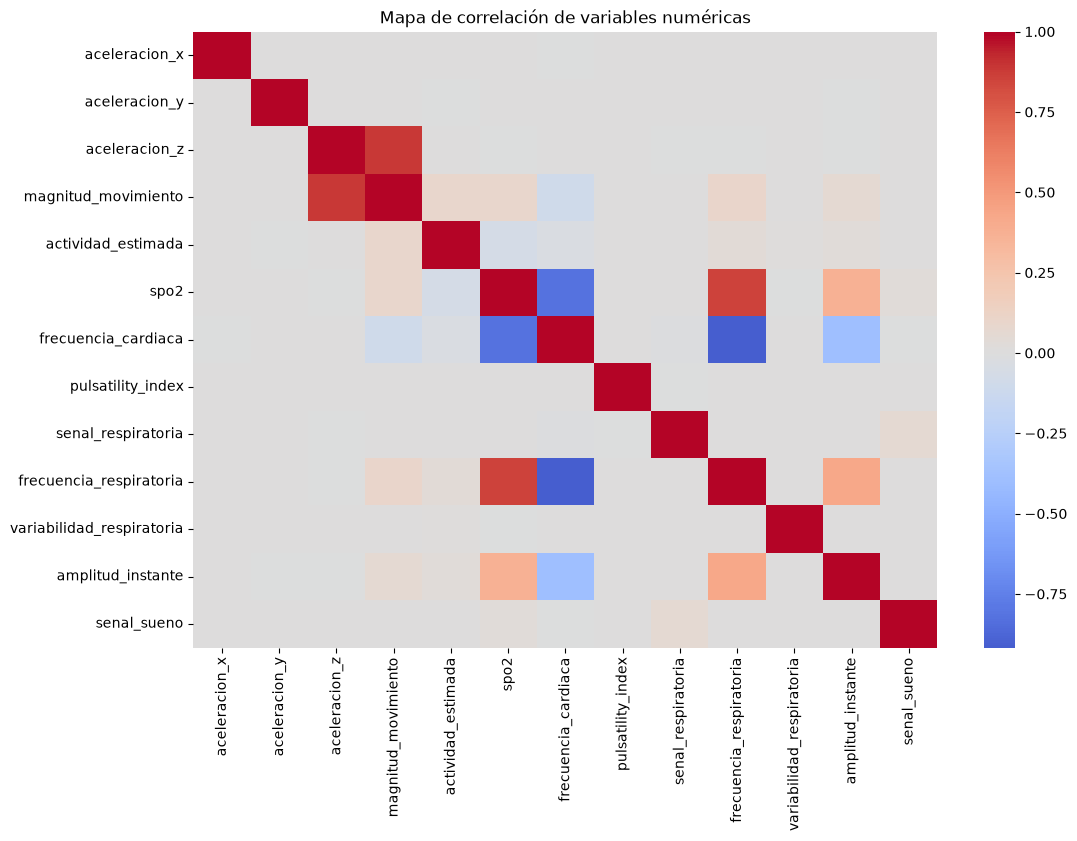

In [31]:
plt.figure(figsize=(12, 8))
num_cols = [
            'aceleracion_x', 'aceleracion_y', 'aceleracion_z',
            'magnitud_movimiento', 'actividad_estimada',
            'spo2', 'frecuencia_cardiaca', 'pulsatility_index',
            'senal_respiratoria', 'frecuencia_respiratoria',
            'variabilidad_respiratoria', 'amplitud_instante',
            'senal_sueno'
        ]

corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Mapa de correlación de variables numéricas")
plt.show()

In [32]:
variables_clave = ['spo2', 'frecuencia_cardiaca', 'frecuencia_respiratoria', 'actividad_estimada']

fig = px.scatter_matrix(
    df[variables_clave].dropna(),
    dimensions=variables_clave,
    color="frecuencia_cardiaca",
    title="Relaciones entre variables clave (Scatter Matrix)"
)

fig.update_traces(diagonal_visible=True)
fig.update_layout(
    width=900,
    height=900,
    dragmode='select'
)

fig.show()

In [33]:
# Scatter 3D
fig = px.scatter_3d(df, x="frecuencia_cardiaca", y="spo2", z="frecuencia_respiratoria",
                    color="fase_ela", symbol="empeoramiento",
                    title="Distribución 3D de variables fisiológicas")
fig.update_traces(marker=dict(size=4))
fig.show()

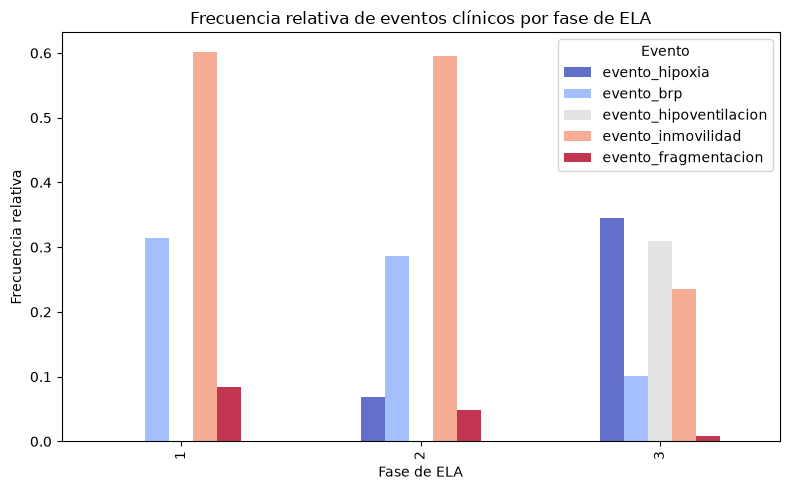

In [34]:
# Sumar eventos por fase
eventos_fase = df.groupby('fase_ela')[['evento_hipoxia', 'evento_brp', 'evento_hipoventilacion', 'evento_inmovilidad', 'evento_fragmentacion']].sum()

# Normalizar para obtener frecuencias relativas
eventos_fase_rel = eventos_fase.div(eventos_fase.sum(axis=1), axis=0)

# Plot
eventos_fase_rel.plot(kind='bar', figsize=(8, 5), colormap='coolwarm', alpha=0.8)
plt.title("Frecuencia relativa de eventos clínicos por fase de ELA")
plt.xlabel("Fase de ELA")
plt.ylabel("Frecuencia relativa")
plt.legend(title="Evento")
plt.tight_layout()
plt.show()

In [35]:
# Plot PCA Interactivo

features = [col for col in num_cols if col not in ["fase_ela", "empeoramiento"]]
X = df[features].fillna(df[features].mean())
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["fase_ela"] = df["fase_ela"]

fig = px.scatter(df_pca, x="PC1", y="PC2", color="fase_ela",
                 title="PCA Interactivo - Distribución por fase ELA",
                 labels={"PC1": "Componente Principal 1", "PC2": "Componente Principal 2"})
fig.show()